In [1]:
# Copyright 2026 Google LLC
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Query local DataFrames with SQL

https://www.ers.usda.gov/data-products/wheat-data


In [2]:
%pip install python-calamine pandas bigframes


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
!wget -O /tmp/wheat-data.xlsx 'https://www.ers.usda.gov/media/5706/wheat-data-all-years.xlsx?v=19753'

--2026-04-09 17:26:58--  https://www.ers.usda.gov/media/5706/wheat-data-all-years.xlsx?v=19753
Resolving www.ers.usda.gov (www.ers.usda.gov)... 20.141.137.224
Connecting to www.ers.usda.gov (www.ers.usda.gov)|20.141.137.224|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 972455 (950K) [application/vnd.openxmlformats-officedocument.spreadsheetml.sheet]
Saving to: ‘/tmp/wheat-data.xlsx’

/tmp/wheat-data.xls 100%[===================>] 949.66K  1.97MB/s    in 0.5s    

2026-04-09 17:26:59 (1.97 MB/s) - ‘/tmp/wheat-data.xlsx’ saved [972455/972455]



In [9]:
import pandas as pd

df = pd.read_excel(
    "/tmp/wheat-data.xlsx",
    sheet_name="Table06",
    header=1,

    # Requires that the python-calamine project is also installed.
    engine="calamine",

    # Recommended so that string columns don't contain NaN, which can confuse
    # parquet serialization, which we use to read these data in BigQuery SQL.
    dtype_backend="pyarrow",
)
df

,Marketing year 1/,Type 2/,Beginning stocks,Production,Imports,Total supply 3/ 4/,Food use,Seed use,Feed and residual use,Total domestic use 4/,Exports,Total disappearance 4/,Ending stocks
0,1950/51,All wheat,496.0,1019.0,11,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
1,1951/52,All wheat,492.0,988.0,30,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
2,1952/53,All wheat,330.0,1306.0,24,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0
3,1953/54,All wheat,672.0,1173.0,6,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0
4,1954/55,All wheat,994.0,984.0,3,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,"2/ Hard Red Winter, Hard Red Spring, Soft Red ...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
288,3/ Includes flour and selected other products ...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
289,4/ Totals may not add due to rounding.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
290,"Source: USDA, Economic Research Service, based...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [23]:
# To aid in SQL authoring, rename the columns to avoid problematic special
# characters.  Note: BigQuery supports some special characters, but not "/".
# https://docs.cloud.google.com/bigquery/docs/schemas#flexible-column-names
df_renamed = df.rename(
    columns={
        column: column.replace("/", "")
        for column in df.columns
    }
)

# Also, give a name to the index so that it can be included.
df_renamed.index.name = "rowindex"
df_renamed


,Marketing year 1,Type 2,Beginning stocks,Production,Imports,Total supply 3 4,Food use,Seed use,Feed and residual use,Total domestic use 4,Exports,Total disappearance 4,Ending stocks
rowindex,,,,,,,,,,,,,
0,1950/51,All wheat,496.0,1019.0,11,1526.0,580.0,--,109.0,689.0,345.0,1034.0,492.0
1,1951/52,All wheat,492.0,988.0,30,1510.0,585.0,--,110.0,695.0,485.0,1180.0,330.0
2,1952/53,All wheat,330.0,1306.0,24,1660.0,578.0,--,78.0,656.0,332.0,988.0,672.0
3,1953/54,All wheat,672.0,1173.0,6,1851.0,556.0,--,87.0,643.0,214.0,857.0,994.0
4,1954/55,All wheat,994.0,984.0,3,1981.0,552.0,--,53.0,605.0,267.0,872.0,1109.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
287,"2/ Hard Red Winter, Hard Red Spring, Soft Red ...",<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
288,3/ Includes flour and selected other products ...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
289,4/ Totals may not add due to rounding.,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [5]:
import bigframes.pandas as bpd

# TODO(developer): Follow the instructions at
# https://docs.cloud.google.com/bigquery/docs/sandbox and set the project to the
# ID of the project you created.
bpd.options.bigquery.project = "swena-bq-sandbox"

In [31]:
%%bqsql df_with_year
SELECT
  REGEXP_EXTRACT(LTRIM(`Marketing year 1`), r'^([0-9]+)/[0-9]') AS `Start year`,
  SAFE_CAST(`Seed use` AS FLOAT64) AS `Seed use`,
  * EXCEPT (`Marketing year 1`, `Seed use`)
FROM {df_renamed}
ORDER BY rowindex ASC

,Start year,Seed use,rowindex,Type 2,Beginning stocks,Production,Imports,Total supply 3 4,Food use,Feed and residual use,Total domestic use 4,Exports,Total disappearance 4,Ending stocks
0,1950,<NA>,0,All wheat,496.0,1019.0,11,1526.0,580.0,109.0,689.0,345.0,1034.0,492.0
1,1951,<NA>,1,All wheat,492.0,988.0,30,1510.0,585.0,110.0,695.0,485.0,1180.0,330.0
2,1952,<NA>,2,All wheat,330.0,1306.0,24,1660.0,578.0,78.0,656.0,332.0,988.0,672.0
3,1953,<NA>,3,All wheat,672.0,1173.0,6,1851.0,556.0,87.0,643.0,214.0,857.0,994.0
4,1954,<NA>,4,All wheat,994.0,984.0,3,1981.0,552.0,53.0,605.0,267.0,872.0,1109.0
5,1955,<NA>,5,All wheat,1109.0,937.0,10,2056.0,553.0,51.0,604.0,322.0,926.0,1130.0
6,1956,<NA>,6,All wheat,1130.0,1005.0,8,2143.0,541.0,57.0,598.0,541.0,1139.0,1004.0
7,1957,<NA>,7,All wheat,1004.0,956.0,10,1970.0,547.0,43.0,590.0,418.0,1008.0,962.0
8,1958,<NA>,8,All wheat,962.0,1457.0,8,2427.0,561.0,48.0,609.0,450.0,1059.0,1368.0
9,1959,<NA>,9,All wheat,1368.0,1118.0,7,2493.0,558.0,49.0,607.0,502.0,1109.0,1384.0


In [34]:
%%bqsql use_proportions
SELECT
  `rowindex`,
  `Start year`,
  `Seed use` / `Total disappearance 4` AS `Seed proportion`,
  `Food use` / `Total disappearance 4` AS `Food proportion`,
  `Feed and residual use` / `Total disappearance 4` AS `Feed proportion`,
  `Exports` / `Total disappearance 4` AS `Exports proportion`
FROM {df_with_year}
WHERE TRIM(`Type 2`) = 'All wheat'
ORDER BY `rowindex` ASC;

,rowindex,Start year,Seed proportion,Food proportion,Feed proportion,Exports proportion
0,0,1950,<NA>,0.560928,0.105416,0.333656
1,1,1951,<NA>,0.495763,0.09322,0.411017
2,2,1952,<NA>,0.58502,0.078947,0.336032
3,3,1953,<NA>,0.648775,0.101517,0.249708
4,4,1954,<NA>,0.633028,0.06078,0.306193
5,5,1955,<NA>,0.597192,0.055076,0.347732
6,6,1956,<NA>,0.474978,0.050044,0.474978
7,7,1957,<NA>,0.542659,0.042659,0.414683
8,8,1958,<NA>,0.529745,0.045326,0.424929
9,9,1959,<NA>,0.503156,0.044184,0.45266


<Axes: xlabel='Start year'>

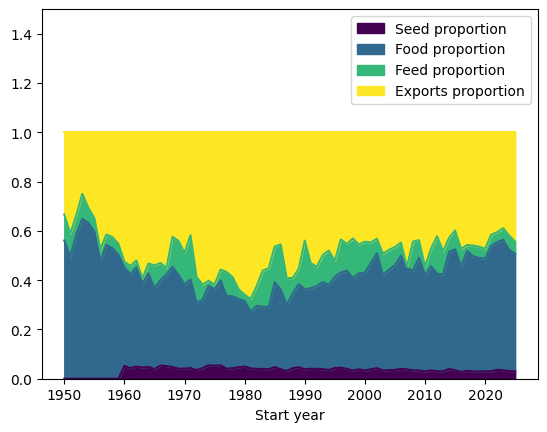

In [43]:
use_proportions.set_index('Start year')[['Seed proportion', 'Food proportion', 'Feed proportion', 'Exports proportion']].plot.area(stacked=True, ylim=(0, 1.5), colormap='viridis')

In [44]:
type(use_proportions)

bigframes.dataframe.DataFrame

In [47]:
pandas_result = use_proportions.to_pandas()
pandas_result

,rowindex,Start year,Seed proportion,Food proportion,Feed proportion,Exports proportion
0,0,1950,<NA>,0.560928,0.105416,0.333656
1,1,1951,<NA>,0.495763,0.09322,0.411017
2,2,1952,<NA>,0.58502,0.078947,0.336032
3,3,1953,<NA>,0.648775,0.101517,0.249708
4,4,1954,<NA>,0.633028,0.06078,0.306193
...,...,...,...,...,...,...
71,256,2021,0.03016,0.507769,0.04614,0.415931
72,262,2022,0.036441,0.517907,0.040243,0.405409
73,268,2023,0.034187,0.52968,0.047175,0.388957
74,274,2024,0.031025,0.492291,0.05731,0.419374
